In [37]:
# ==========================================
# ML Foundations Capstone Project
# Notebook 1: Data Cleaning
# ==========================================

# In this notebook all the data will be cleaned.
# Goal:Load the dataset, inspect problems, and create a clean DataFrame.


In [38]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# Load the Data
df= pd.read_csv("C:\\Users\\MOJ\\Desktop\\semester 2\\Capstone project\\data\\AmesHousing.csv")

In [40]:
#copying the data 
df_copy = df.copy()

In [41]:
# Preview the first 5 rows
df_copy.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [42]:
# Checking the shape

print(f'rows : {df_copy.shape[0]}, Columns : {df_copy.shape[1]}')

rows : 2930, Columns : 82


In [43]:
#checking the info
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [44]:
# Fixing data

df_copy['M(S SubClass'] = df_copy['MS SubClass'].astype('category')      
# Converted to categorical because the numbers are codes representing building types and not real numeric values

df_copy['MS Zoning'] = df_copy['MS Zoning'].astype('category')          
# Converted to categorical because this column represents land use categories

df_copy['Lot Frontage'] = pd.to_numeric(df_copy['Lot Frontage'], errors='coerce')  
# Converted to numeric because this represents the frontage length of the lot, used for calculations

df_copy['Lot Area'] = pd.to_numeric(df_copy['Lot Area'], errors='coerce')          
# Converted to numeric because this represents lot area in square feet

df_copy['Year Built'] = pd.to_numeric(df_copy['Year Built'], errors='coerce')      
# Converted to numeric because year built is a number useful for calculations (like house age)

# Check after fixing
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 83 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Order            2930 non-null   int64   
 1   PID              2930 non-null   int64   
 2   MS SubClass      2930 non-null   int64   
 3   MS Zoning        2930 non-null   category
 4   Lot Frontage     2440 non-null   float64 
 5   Lot Area         2930 non-null   int64   
 6   Street           2930 non-null   object  
 7   Alley            198 non-null    object  
 8   Lot Shape        2930 non-null   object  
 9   Land Contour     2930 non-null   object  
 10  Utilities        2930 non-null   object  
 11  Lot Config       2930 non-null   object  
 12  Land Slope       2930 non-null   object  
 13  Neighborhood     2930 non-null   object  
 14  Condition 1      2930 non-null   object  
 15  Condition 2      2930 non-null   object  
 16  Bldg Type        2930 non-null   object  


In [45]:
# checking the missing values

print("Missing values per column:")
print(df_copy.isnull().sum())

df_copy['Lot Frontage'] = df_copy['Lot Frontage'].fillna(df_copy['Lot Frontage'].median())
# used fillna to fill the missing values with median to avoid losing data and reduce effect of outliers

if 'Alley' in df_copy.columns:
    df_copy['Alley'] = df_copy['Alley'].fillna('None')
# used because missing values indicate no alley access

if 'MasVnrType' in df_copy.columns:
    df_copy['MasVnrType'] = df_copy['MasVnrType'].fillna('None')
# used because missing values mean no masonry veneer

if 'MasVnrArea' in df_copy.columns:
    df_copy['MasVnrArea'] = df_copy['MasVnrArea'].fillna(0)
# used because missing area means no veneer, so 0 is appropriate

basement_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in basement_cols:
    if col in df_copy.columns:
        df_copy[col] = df_copy[col].fillna('None')
# used because the missing -basement related- values indicate no basement

if 'Functional' in df_copy.columns:
    df_copy['Functional'] = df_copy['Functional'].fillna('Typ')
    # used fillna('Typ') because it is the most common and reasonable default value


print("\nMissing values after handling:")
print(df_copy.isnull().sum())


Missing values per column:
Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
M(S SubClass        0
Length: 83, dtype: int64

Missing values after handling:
Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
M(S SubClass      0
Length: 83, dtype: int64


In [46]:
# checking the duplicated values

print('the number of duplicated rows is:', df_copy.duplicated().sum())
df_copy = df_copy.drop_duplicates()
print(' the number of duplicated rows after dropping is:', df_copy.duplicated().sum())

the number of duplicated rows is: 0
 the number of duplicated rows after dropping is: 0



Max value before capping:
755000


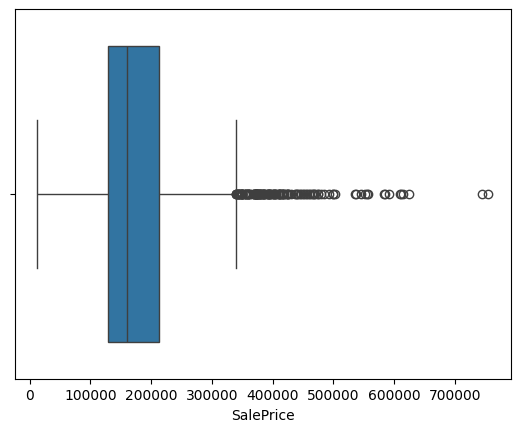


Max value after capping:
456666.3700000001


In [47]:
# Checking for outliers in SalePrice using boxplot and capping

print("\nMax value before capping:")
print(df_copy['SalePrice'].max())
sns.boxplot(x=df_copy['SalePrice'])
plt.show()
cap = df_copy['SalePrice'].quantile(0.99)
df_copy['SalePrice'] = df_copy['SalePrice'].clip(upper=cap)

print("\nMax value after capping:")
print(df_copy['SalePrice'].max())

In [48]:
# clean data function so it can be reused

def clean_data(df):
    # Fix data types
    df_copy['MSSubClass'] = df['MSSubClass'].astype('category')
    df_copy['MSZoning'] = df['MSZoning'].astype('category')
    df_copy['LotFrontage'] = pd.to_numeric(df['LotFrontage'], errors='coerce')
    df_copy['LotArea'] = pd.to_numeric(df['LotArea'], errors='coerce')
    df_copy['YearBuilt'] = pd.to_numeric(df['YearBuilt'], errors='coerce')

    # Handle missing values
    df_copy['LotFrontage'] = df_copy['LotFrontage'].fillna(df_copy['LotFrontage'].median())
    if 'Alley' in df_copy.columns:
        df_copy['Alley'] = df_copy['Alley'].fillna('None')
    if 'MasVnrType' in df_copy.columns:
        df_copy['MasVnrType'] = df_copy['MasVnrType'].fillna('None')
    if 'MasVnrArea' in df_copy.columns:
        df_copy['MasVnrArea'] = df_copy['MasVnrArea'].fillna(0)

    basement_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
    for col in basement_cols:
        if col in df_copy.columns:
            df_copy[col] = df_copy[col].fillna('None')

    if 'Functional' in df_copy.columns:
        df_copy['Functional'] = df_copy['Functional'].fillna('Typ')

    # Handle duplicates
    df_copy = df_copy.drop_duplicates()

    # Handle outliers (target: SalePrice)
    cap = df_copy['SalePrice'].quantile(0.99)
    df_copy['SalePrice'] = df_copy['SalePrice'].clip(upper=cap)

    return df_copy

print("\nData cleaning completed. Final shape:", df_copy.shape)


Data cleaning completed. Final shape: (2930, 83)


In [49]:
# Check 1: No missing values in key columns
key_columns = ['SalePrice', 'Lot Area', 'Year Built']

print("Missing values in key columns:\n",df_copy[key_columns].isnull().sum())

# Check 2: All target values must be greater than 0
print("\nAll SalePrice values are positive:", (df_copy['SalePrice'] > 0).all())

# check 3: Verify expected number of columns
print("\nNumber of columns:", df_copy.shape[1])


Missing values in key columns:
 SalePrice     0
Lot Area      0
Year Built    0
dtype: int64

All SalePrice values are positive: True

Number of columns: 83


In [50]:
# making a csv file that saves the cleaned data into to use it in another files
df_copy.to_csv("clean_data.csv", index=False)
